In [2]:
!pip install thop

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import torch

torch.cuda.set_device(4)
device = torch.device("cuda:4")

print("Current device index:", torch.cuda.current_device())
print("Current device name:", torch.cuda.get_device_name(4))

Current device index: 4
Current device name: Tesla V100-PCIE-32GB


/home/mtech/2025/poulami.mukherjee25m/.local/lib/python3.6/site-packages/torch/cuda/__init__.py:143: UserWarning: 
NVIDIA A100-PCIE-40GB with CUDA capability sm_80 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_70.
If you want to use the NVIDIA A100-PCIE-40GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(incompatible_device_warn.format(device_name, capability, " ".join(arch_list), device_name))


Files already downloaded and verified
Files already downloaded and verified
FLOPs: 305.073M
Params: 769.162K
Epoch 1: Train 49.79% | Test 58.23%
Epoch 2: Train 68.33% | Test 68.37%
Epoch 3: Train 75.89% | Test 74.43%
Epoch 4: Train 79.65% | Test 75.73%
Epoch 5: Train 81.76% | Test 81.26%
Epoch 6: Train 83.79% | Test 75.14%
Epoch 7: Train 84.88% | Test 82.54%
Epoch 8: Train 85.87% | Test 82.92%
Epoch 9: Train 86.71% | Test 81.90%
Epoch 10: Train 87.36% | Test 77.62%
Epoch 11: Train 87.68% | Test 84.88%
Epoch 12: Train 88.30% | Test 84.93%
Epoch 13: Train 88.50% | Test 85.77%
Epoch 14: Train 89.24% | Test 87.38%
Epoch 15: Train 89.37% | Test 84.38%
Epoch 16: Train 89.45% | Test 86.64%
Epoch 17: Train 89.80% | Test 83.26%
Epoch 18: Train 89.59% | Test 84.15%
Epoch 19: Train 89.91% | Test 88.41%
Epoch 20: Train 90.06% | Test 85.11%
Epoch 21: Train 90.20% | Test 82.94%
Epoch 22: Train 90.45% | Test 86.16%
Epoch 23: Train 90.50% | Test 86.26%
Epoch 24: Train 90.63% | Test 87.66%
Epoch 25: Tr

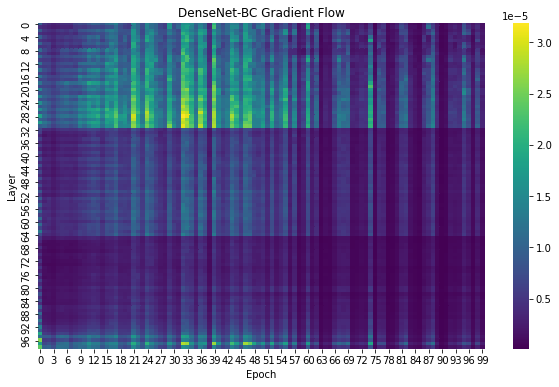

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Data (C10+)
# -----------------------------
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# -----------------------------
# DenseNet-BC (k=12, L=100)
# -----------------------------
growth_rate = 12
depth = 100
compression = 0.5
nblocks = (depth - 4) // 6  # BC → divide by 6

class DenseLayer(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        inter_channels = 4 * growth_rate

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, bias=False)

        self.bn2 = nn.BatchNorm2d(inter_channels)
        self.conv2 = nn.Conv2d(inter_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(torch.relu(self.bn1(x)))
        out = self.conv2(torch.relu(self.bn2(out)))
        return torch.cat([x, out], 1)


class Transition(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        out_channels = int(in_channels * compression)

        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(2)

    def forward(self, x):
        x = self.conv(torch.relu(self.bn(x)))
        return self.pool(x)


class DenseNetBC(nn.Module):
    def __init__(self):
        super().__init__()

        num_channels = 2 * growth_rate  # BC rule

        self.conv1 = nn.Conv2d(3, num_channels, kernel_size=3, padding=1, bias=False)

        # Block 1
        self.block1 = self._make_block(num_channels)
        num_channels += nblocks * growth_rate
        self.trans1 = Transition(num_channels)
        num_channels = int(num_channels * compression)

        # Block 2
        self.block2 = self._make_block(num_channels)
        num_channels += nblocks * growth_rate
        self.trans2 = Transition(num_channels)
        num_channels = int(num_channels * compression)

        # Block 3
        self.block3 = self._make_block(num_channels)
        num_channels += nblocks * growth_rate

        self.bn = nn.BatchNorm2d(num_channels)
        self.fc = nn.Linear(num_channels, 10)

    def _make_block(self, in_channels):
        layers = []
        for _ in range(nblocks):
            layers.append(DenseLayer(in_channels))
            in_channels += growth_rate
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.trans1(self.block1(x))
        x = self.trans2(self.block2(x))
        x = self.block3(x)
        x = torch.relu(self.bn(x))
        x = torch.nn.functional.avg_pool2d(x, 8)
        x = x.view(x.size(0), -1)
        return self.fc(x)


model = DenseNetBC().to(device)

# -----------------------------
# FLOPs + Params
# -----------------------------
from thop import profile, clever_format

dummy = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy,), verbose=False)
flops, params = clever_format([flops, params], "%.3f")

print("FLOPs:", flops)
print("Params:", params)  # ~0.8M expected

# -----------------------------
# Gradient Hooks
# -----------------------------
gradients = {}
grad_history = []

def hook_fn(name):
    def hook(module, grad_input, grad_output):
        gradients[name] = grad_output[0].abs().mean().item()
    return hook

for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv2d):
        layer.register_full_backward_hook(hook_fn(name))

# -----------------------------
# Training Setup
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[50, 75],
    gamma=0.1
)

num_epochs = 100

history = {
    "Epoch": [],
    "Train Accuracy": [],
    "Test Accuracy Top1": [],
    "Test Accuracy Top5": [],
    "Train Loss": [],
    "Test Loss": [],
    "Precision": [],
    "Recall": []
}

# -----------------------------
# Evaluation
# -----------------------------
def evaluate(loader):
    model.eval()
    total_loss, correct1, correct5, total = 0, 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

            _, p1 = out.max(1)
            correct1 += p1.eq(y).sum().item()

            _, p5 = out.topk(5, dim=1)
            correct5 += sum(y[i] in p5[i] for i in range(y.size(0)))

            total += y.size(0)

            all_preds.extend(p1.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    acc1 = 100 * correct1 / total
    acc5 = 100 * correct5 / total
    loss = total_loss / len(loader)

    precision = precision_score(all_targets, all_preds, average='macro')
    recall = recall_score(all_targets, all_preds, average='macro')

    return loss, acc1, acc5, precision, recall

# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(num_epochs):
    model.train()

    running_loss, correct, total = 0, 0, 0

    for i, (x, y) in enumerate(trainloader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        if i == 0:
            grad_history.append(list(gradients.values()))

        optimizer.step()

        running_loss += loss.item()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    test_loss, test_acc1, test_acc5, precision, recall = evaluate(testloader)

    scheduler.step()

    history["Epoch"].append(epoch+1)
    history["Train Accuracy"].append(train_acc)
    history["Test Accuracy Top1"].append(test_acc1)
    history["Test Accuracy Top5"].append(test_acc5)
    history["Train Loss"].append(train_loss)
    history["Test Loss"].append(test_loss)
    history["Precision"].append(precision)
    history["Recall"].append(recall)

    print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Test {test_acc1:.2f}%")

# -----------------------------
# Save
# -----------------------------
torch.save(model.state_dict(), "densenet_bc_100.pth")
pd.DataFrame(history).to_excel("densenet_bc_results.xlsx", index=False)

# -----------------------------
# Gradient Heatmap
# -----------------------------
grad_matrix = np.array(grad_history).T

plt.figure(figsize=(10,6))
sns.heatmap(grad_matrix, cmap="viridis")
plt.title("DenseNet-BC Gradient Flow")
plt.xlabel("Epoch")
plt.ylabel("Layer")
plt.show()

In [4]:
# -----------------------------
# FINAL TEST EVALUATION
# -----------------------------
model.eval()

total = 0
correct_top1 = 0
correct_top5 = 0
total_loss = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        total_loss += loss.item()

        # Top-1
        _, pred_top1 = outputs.max(1)
        correct_top1 += pred_top1.eq(targets).sum().item()

        # Top-5
        _, pred_top5 = outputs.topk(5, dim=1)
        correct_top5 += sum([
            targets[i] in pred_top5[i] for i in range(targets.size(0))
        ])

        total += targets.size(0)

        all_preds.extend(pred_top1.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# -----------------------------
# Final Metrics
# -----------------------------
final_test_acc_top1 = 100. * correct_top1 / total
final_test_acc_top5 = 100. * correct_top5 / total
final_test_loss = total_loss / len(testloader)

from sklearn.metrics import precision_score, recall_score
precision = precision_score(all_targets, all_preds, average='macro')
recall = recall_score(all_targets, all_preds, average='macro')

test_error = 100 - final_test_acc_top1

print("\n================ FINAL TEST RESULTS (DenseNet-BC) ================")
print(f"Top-1 Accuracy  : {final_test_acc_top1:.2f}%")
print(f"Top-5 Accuracy  : {final_test_acc_top5:.2f}%")
print(f"Test Loss       : {final_test_loss:.4f}")
print(f"Test Error %    : {test_error:.2f}%")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print("=================================================================")


================ FINAL TEST RESULTS (DenseNet-BC) ================
Top-1 Accuracy  : 93.98%
Top-5 Accuracy  : 99.85%
Test Loss       : 0.2362
Test Error %    : 6.02%
Precision       : 0.9400
Recall          : 0.9398


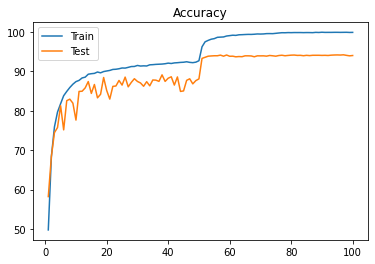

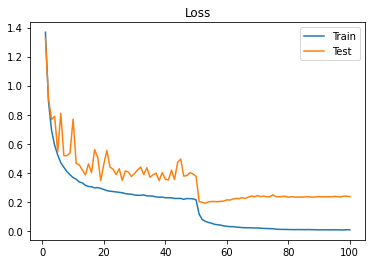

In [12]:
# Plots
# -----------------------------
plt.plot(history["Epoch"], history["Train Accuracy"], label="Train")
plt.plot(history["Epoch"], history["Test Accuracy Top1"], label="Test")
plt.legend(); plt.title("Accuracy"); plt.show()

plt.plot(history["Epoch"], history["Train Loss"], label="Train")
plt.plot(history["Epoch"], history["Test Loss"], label="Test")
plt.legend(); plt.title("Loss"); plt.show()
